LSTM DPD

In [2]:
%reset -f
from scipy.io import loadmat
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from pyrfdpd.utils import plot
from function import PA_DVR
import TEST_Plot 
torch.cuda.is_available()

True

In [3]:
# 读取PA输入输出信号
data_file = 'data/signal_20M_NR_fs100.mat'
# data_file = 'data/signal_100M_NR_fs49152.mat'

x_data = loadmat(data_file)
# xorg = x_data[]
xorg = x_data['signal_20M_NR_fs100'][0:16384]
xorg = xorg / max(abs(xorg))
yorg = PA_DVR.PA_DVR_v1(xorg).reshape(-1, 1)
yorg = yorg / max(abs(yorg))
x = xorg.squeeze()
y = yorg.squeeze()
# y_data = loadmat(result_file)
# yorg = y_data['y_sync_01'].reshape(-1)
# yorg = yorg / max(abs(yorg))

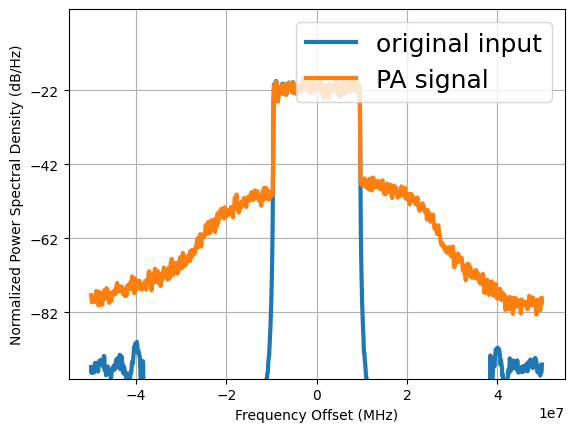

In [4]:
fs = 100e6
# import TEST_Plot
plot.psd(
    {"original input": x,"PA signal":y},
    fs=fs,filename='figures/DPD.png'
)
# a = list(xorg)
# TEST_Plot.plot_power_spectrum(yorg,100e6)
# TEST_Plot.plot_amam(x, y,filename="figures/amam wo DPD.png")
# plot.ampm(xorg, yorg, "figures/ampm wo DPD.png")
# Plot.plot_power_spectrum(xorg,100e6)

In [1]:
TEST_Plot.plot_amam(x, y,filename="figures/amam wo DPD.png")

NameError: name 'TEST_Plot' is not defined

In [4]:
# 假设xorg和yorg是已经对齐的复数信号（numpy数组）
# 这里生成示例数据，实际使用时替换为真实数据
N = 16384  # 信号长度
# xorg = np.random.randn(N) + 1j*np.random.randn(N)  # 原始信号（PA输入）
# yorg = np.random.randn(N) + 1j*np.random.randn(N)  # PA输出信号

# 数据预处理：将复数转换为实部+虚部
def complex_to_real(x):
    return np.stack((x.real, x.imag), axis=1)

# 创建数据集
X = complex_to_real(y)  # 输入：PA输出信号
Y = complex_to_real(x)  # 目标：原始信号

In [5]:

# 转换为PyTorch张量
X_tensor = torch.FloatTensor(X)
Y_tensor = torch.FloatTensor(Y)

# 划分训练集和测试集
X_train, X_val, Y_train, Y_val = train_test_split(
    X_tensor, Y_tensor, test_size=0.2, shuffle=False)

# 创建数据加载器
batch_size = 128
train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val, Y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [109]:

# 定义LSTM模型
class DPDModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=2, output_size=2):
        super(DPDModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # 添加序列维度（batch_size, sequence_length=1, input_size）
        x = x.unsqueeze(1)
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # 只取最后一个时间步的输出
        return out

# 初始化模型
model = DPDModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练循环
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # 验证
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            outputs = model(inputs)
            val_loss += criterion(outputs, targets).item()
    
    print(f'Epoch {epoch+1:02} | Train Loss: {train_loss/len(train_loader):.6f} | Val Loss: {val_loss/len(val_loader):.6f}')


Epoch 01 | Train Loss: 0.032593 | Val Loss: 0.004333
Epoch 02 | Train Loss: 0.000568 | Val Loss: 0.000219
Epoch 03 | Train Loss: 0.000234 | Val Loss: 0.000204
Epoch 04 | Train Loss: 0.000229 | Val Loss: 0.000202
Epoch 05 | Train Loss: 0.000227 | Val Loss: 0.000203
Epoch 06 | Train Loss: 0.000228 | Val Loss: 0.000200
Epoch 07 | Train Loss: 0.000229 | Val Loss: 0.000214
Epoch 08 | Train Loss: 0.000229 | Val Loss: 0.000198
Epoch 09 | Train Loss: 0.000227 | Val Loss: 0.000198
Epoch 10 | Train Loss: 0.000228 | Val Loss: 0.000199
Epoch 11 | Train Loss: 0.000230 | Val Loss: 0.000205
Epoch 12 | Train Loss: 0.000226 | Val Loss: 0.000204
Epoch 13 | Train Loss: 0.000227 | Val Loss: 0.000193
Epoch 14 | Train Loss: 0.000229 | Val Loss: 0.000208
Epoch 15 | Train Loss: 0.000229 | Val Loss: 0.000194
Epoch 16 | Train Loss: 0.000227 | Val Loss: 0.000199
Epoch 17 | Train Loss: 0.000224 | Val Loss: 0.000202
Epoch 18 | Train Loss: 0.000224 | Val Loss: 0.000193
Epoch 19 | Train Loss: 0.000224 | Val Loss: 0.

In [ ]:

# 生成预失真信号
def apply_dpd(model, y_signal):
    model.eval()
    with torch.no_grad():
        # 转换输入格式
        y_real = torch.FloatTensor(y_signal.real.reshape(-1, 1))
        y_imag = torch.FloatTensor(y_signal.imag.reshape(-1, 1))
        y_input = torch.cat((y_real, y_imag), dim=1)
        
        # 预测
        pred = model(y_input).numpy()
        return pred[:, 0] + 1j*pred[:, 1]

# 使用训练好的模型处理信号
predistorted_signal = apply_dpd(model, x)

# # 评估结果（示例）
# mse = np.mean(np.abs(xorg - predistorted_signal)**2)
# print(f"Prediction MSE: {mse:.6f}")

Prediction MSE: 0.166732


In [ ]:
PA_out = PA_DVR.PA_DVR_v1(x)
# 评估结果（示例）
mse = np.mean(np.abs(x - PA_out)**2)
print(f"MSE with DPD: {mse:.6f}")
mse = np.mean(np.abs(x - y)**2)
print(f"MSE with DPD: {mse:.6f}")
fs = 100e6
plot.psd(
    {"original input": x,"PA signal":PA_out,"DPD signal":predistorted_signal},
    fs=fs,filename='figures/with_DPD.png'
)

Prediction MSE: 0.001196


In [ ]:
TEST_Plot.plot_power_spectrum(y,100e6)
TEST_Plot.plot_power_spectrum(xorg,100e6)